In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

In [3]:
manifest['src_fn'][0]

'/scratch2/weka/mcdermott/msaddler/swc/english/validArticles/Binary_star/audio_combined.wav'

In [4]:
manifest['excerpt_src_fn'][0]

'/om/user/imgriff/datasets/human_word_rec_SWC_2024/sounds/target_excerpts/full_df_ix_0000_about-laura-s.wav'

## Load participant data and meta files 

In [5]:
## Get all participant data into one df for analysis
def get_part_df(fname):
    part_df = pd.read_csv(fname)
    part_df = part_df[part_df.trial_type == 'dictionary-text'].reset_index(drop=True)
    part_df.trial_num = part_df.trial_num.astype(float).astype('int')
    # part_df['participant'] = fname.stem
    return part_df

def slice_transcript_path(path_str):
    return Path(path_str).stem

def unpack_loc_tuple(loc_tup):
    if isinstance(loc_tup[0], tuple):
        n_dist = 2 
        loc_tup = loc_tup[0]
    else:
        n_dist = 1
    azim, elev = loc_tup 
    azim = abs(azim)
    return azim, elev, n_dist

def unpack_dist_words(dist_word_list):
    if isinstance(dist_word_list, list):
        dist_1_word, dist_2_word = dist_word_list
    else:
        dist_1_word, dist_2_word = dist_word_list, None
    return dist_1_word, dist_2_word

def unpack_trial_from_array_manifest(trial):
    target_loc = trial[0]
    distractor_loc = trial[1]
    snr = trial[2]
    cue_src_fn = trial[3][0].stem
    src_fn = trial[4][0].stem
    dist_fn = trial[5]
    
    if len(dist_fn) == 1:
        distractor_1_fn = dist_fn[0].stem
        distractor_2_fn = None
    else:
        distractor_1_fn = dist_fn[0].stem
        distractor_2_fn =dist_fn[1].stem

    return target_loc, distractor_loc, snr, cue_src_fn, src_fn, distractor_1_fn, distractor_2_fn

def get_manifest_df(fname):
    manifest = pd.read_pickle(fname)
    array_manifest_fname = str(fname).replace("meta", "array_manifest")
    trial_manifest = pd.read_pickle(array_manifest_fname)
    # add trial_manifest contents to manifest 
    _, _, _, _, src_fn, dist_1_fn, dist_2_fn = zip(*[unpack_trial_from_array_manifest(trial) for trial in trial_manifest])
    manifest_df = pd.concat([pd.DataFrame(val.values()) for val in manifest.values()]).reset_index(drop=True)
    trial_nums =  manifest_df.index.to_list()
    manifest_df['trial_num'] = trial_nums
    # unpack locations to azimuth and elevation 
    manifest_df['target_azim'] = manifest_df['target_loc'].apply(lambda x: x[0])
    manifest_df['target_elev'] = manifest_df['target_loc'].apply(lambda x: x[1])
    dist_azim, dist_elev, n_dist = zip(*manifest_df['distractor_loc'].apply(lambda x: unpack_loc_tuple(x)))
    manifest_df['distractor_azim'] = dist_azim
    manifest_df['distractor_elev'] = dist_elev
    manifest_df['n_distractors'] = n_dist
    # unpack distractor words 
    dist_1_word, dist_2_word = zip(*manifest_df['distractor_word'].apply(unpack_dist_words))
    manifest_df['distractor_1_word'] = dist_1_word
    manifest_df['distractor_2_word'] = dist_2_word
    # add source and distractor file names
    manifest_df['src_fn'] = [src_fn[ix] for ix in trial_nums]
    manifest_df['distractor_1_fn'] = [dist_1_fn[ix] for ix in trial_nums]
    manifest_df['distractor_2_fn'] = [dist_2_fn[ix] for ix in trial_nums]
    return manifest_df

def get_info_from_trial_dict(fname):
    manifest = pd.read_pickle(fname)
    trials = []
    for ix, trial in enumerate(manifest):
        trial_dict = {}
        trial_dict['target_azim'] = trial[0][0]
        trial_dict['target_elev'] = trial[0][1]
        trial_dict['distractor_azim'] = trial[1][0]
        trial_dict['distractor_elev'] = trial[1][1]
        trial_dict['target_word'] = Path(trial[3]).stem.split('_')[0]
        trial_dict['distractor_word'] = Path(trial[4]).stem.split('_')[0]
        trial_dict['trial_num'] = ix
        trials.append(trial_dict)
    manifest_df = pd.DataFrame(trials)
    return manifest_df


## Get experiment results

In [6]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(slice_transcript_path)


In [7]:
# portion_1 = pd.merge(manifest_df[manifest_df.n_distractors==2],
#  df_w_transcripts[['word', 'distractor_1_word', 'distractor_2_word',
#                  'target_transcripts', 'distractor_1_transcripts', 'distractor_2_transcripts',
#                  'targ_src_stem', 'dist_1_src_stem', 'dist_2_src_stem']],
#             left_on=['target_word', 'distractor_1_word', 'distractor_2_word', 'src_fn', 'distractor_1_fn', 'distractor_2_fn'],
#             right_on=['word', 'distractor_1_word', 'distractor_2_word', 'targ_src_stem', 'dist_1_src_stem', 'dist_2_src_stem'],
#             how='left') 

# portion_2 = pd.merge(manifest_df[manifest_df.n_distractors==1],
#  df_w_transcripts[['word', 'distractor_1_word', 'distractor_2_word',
#                  'target_transcripts', 'distractor_1_transcripts', 'distractor_2_transcripts',
#                  'targ_src_stem', 'dist_1_src_stem', 'dist_2_src_stem']],
#             left_on=['target_word', 'distractor_1_word',  'src_fn', 'distractor_1_fn'],
#              right_on=['word', 'distractor_1_word',  'targ_src_stem', 'dist_1_src_stem'], how='left') 

# # drop rows of portion_2 df that equal portion_1 df 
# pd.concat([portion_1, portion_2])# .drop_duplicates(keep=False)

In [8]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v01')
part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v01/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

## add pilot results 

path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/pilot_thresholds_v00')
part_results += sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_thresholds_v00/')
meta_files += sorted(list(path_to_meta_data.glob("*meta.pkl")))


# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:
    part_name = result_file.stem
    # remove space 
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    manifest_file = manifest_dict[part_name]
    part_df = get_part_df(result_file)
    manifest_df = get_manifest_df(manifest_file)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='left')
    part_df['participant'] = part_name
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)

## add confusions 
confusions = []
for response, distractor_word in results_df[['response', 'distractor_word']].to_numpy():
    if isinstance(distractor_word, list):
        confusions.append(int(response in distractor_word))
    else:
        confusions.append(int(response == distractor_word ))

results_df['confusions'] = confusions

In [9]:
# manifest = pd.read_pickle(manifest_file)
# manifest_df = pd.concat([pd.DataFrame(val.values()) for val in manifest.values()]).reset_index(drop=True)
# manifest_df.head()

In [10]:
manifest_file

PosixPath('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/pilot_thresholds_v00/participant_002_pilot_meta.pkl')

In [11]:
## Drop preston's duplicated trial - is 359 with response: "trees"

results_df = results_df[~((results_df.participant == 'pilot_participant_002') & (results_df.trial_num == 359) & (results_df.response == 'trees'))].reset_index(drop=True)

In [12]:
results_df['distractor_elev_delta'] = (results_df['distractor_elev'] - results_df['target_elev']).abs()

In [13]:
grouped_part_results = results_df.groupby(['participant', 'target_azim', 'target_elev', 'distractor_azim',
                                   'distractor_elev_delta', 'snr', 'n_distractors',]).agg({'correct':['mean', 'sem'],
                                                                                    'confusions':['mean', 'sem', 'count']}).reset_index()
# flatten multiindex
grouped_part_results.columns = ['_'.join(col).strip() for col in grouped_part_results.columns.values]
# remove trailing underscore
grouped_part_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_part_results.columns.values]



In [14]:
# function to calculate Cohen's d for independent samples
# eg from https://machinelearningmastery.com/effect-size-measures-in-python/

def cohend(d1, d2):
	# calculate the size of samples
	n1, n2 = len(d1), len(d2)
	# calculate the variance of the samples
	s1, s2 = np.var(d1, ddof=1), np.var(d2, ddof=1)
	# calculate the pooled standard deviation
	s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
	# calculate the means of the samples
	u1, u2 = np.mean(d1), np.mean(d2)
	# calculate the effect size
	return (u1 - u2) / s


(-10.0, 2.0)

<Figure size 640x480 with 0 Axes>

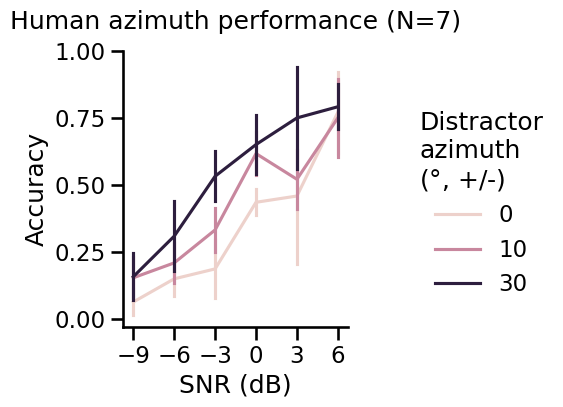

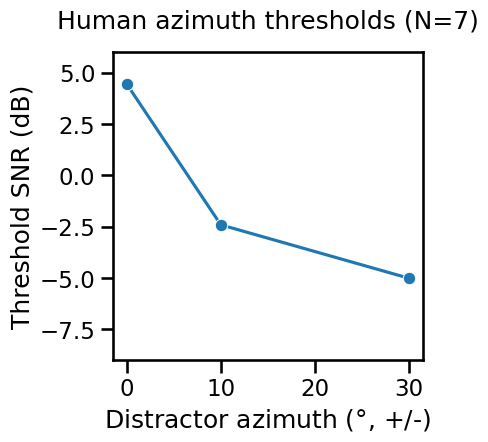

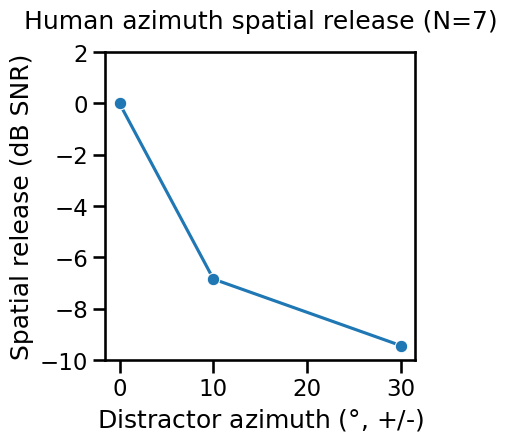

In [15]:
### Make threshold dataframe 

## First, get grand average. Then bootstrap for error 
sns.set_context('talk')

# avg threshold estimates for 0 and 10 azimuth separation 
azim_results = grouped_part_results[(grouped_part_results.distractor_elev_delta == 0) & (grouped_part_results.distractor_azim.isin([0, 10, 30])) & (grouped_part_results.n_distractors == 2)].copy()
azim_results.loc
azim_results_for_thresh = azim_results.groupby(['distractor_azim', 'snr']).agg({'correct_mean':'mean'}).reset_index()
N = azim_results.participant.nunique() 


azim_results_for_thresh = azim_results_for_thresh[azim_results_for_thresh['snr'].isin(np.arange(-9, 7))]

azim_thresholds = []
# p0 = [0.0, -4, 4]
for azim, group in azim_results_for_thresh.groupby(['distractor_azim']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values)#, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for azim {azim}")
    azim_thresholds.append({'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_azim_thresh_df = pd.DataFrame(azim_thresholds)

human_azim_thresh_df['srm'] = human_azim_thresh_df.threshold - human_azim_thresh_df.threshold.max()

plt.figure()
g = sns.relplot(data=azim_results[azim_results.snr.isin(np.arange(-9, 7,3))],
                x='snr', y='correct_mean', hue="distractor_azim",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # col='target_elev', 
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
plt.title(f'Human azimuth performance (N={N})', y=1.05)

# plot azim thresholds
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_azim_thresh_df, x='azim', y='threshold', marker='o')

plt.title(f'Human azimuth thresholds (N={N})', y=1.05)
plt.xlabel('Distractor azimuth ($\degree$, +/-)')
plt.ylabel("Threshold SNR (dB)")
plt.ylim(-9,6)


# plot azim thresholds
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_azim_thresh_df, x='azim', y='srm', marker='o')

plt.title(f'Human azimuth spatial release (N={N})', y=1.05)
plt.xlabel('Distractor azimuth ($\degree$, +/-)')
plt.ylabel("Spatial release (dB SNR)")
plt.ylim(-10,2)

(-10.0, 2.0)

<Figure size 640x480 with 0 Axes>

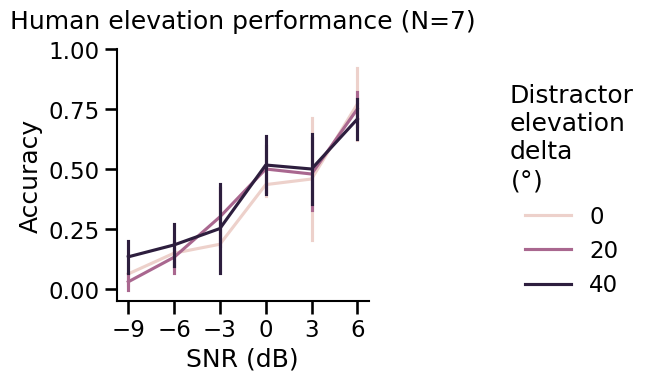

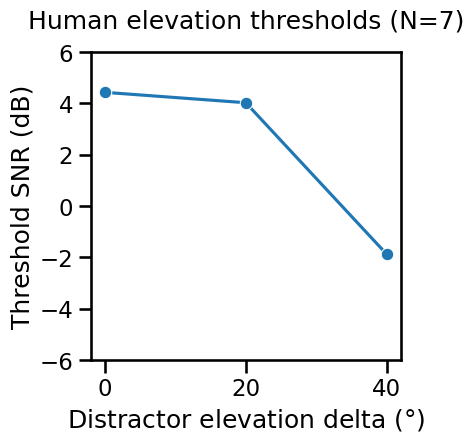

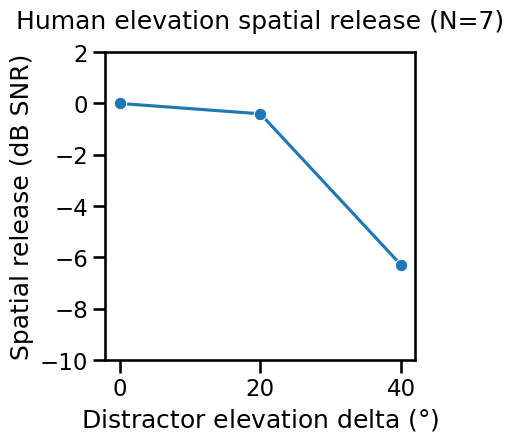

In [16]:
### Make threshold dataframe 

## First, get grand average. Then bootstrap for error 

# avg threshold estimates for 0 and 10 elevuth separation 
elev_results = grouped_part_results[(grouped_part_results.distractor_azim == 0)  & (grouped_part_results.n_distractors == 2)].copy()
elev_results = elev_results[(elev_results['snr'].isin(np.arange(-9, 7)))]

elev_results_for_thresh = elev_results.groupby(['distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()
N = elev_results.participant.nunique() 

# elev_results_for_thresh = elev_results_for_thresh[(elev_results_for_thresh['snr'].isin(np.arange(-9, 7,3)))]

elev_thresholds = []
p0 = None # [0.1, -3, 1]
for elev, group in elev_results_for_thresh.groupby(['distractor_elev_delta']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for elev {elev}")
    elev_thresholds.append({'elev': elev, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_elev_thresh_df = pd.DataFrame(elev_thresholds)


plt.figure()
g = sns.relplot(data=elev_results[elev_results.snr.isin(np.arange(-9, 7,3))],
                x='snr', y='correct_mean', hue="distractor_elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # col='target_elev', 
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1.1)

g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta\n($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
plt.title(f'Human elevation performance (N={N})', y=1.05)
ratio = 1 
# set titles for each column 
for ax in g.axes.flat:
	xleft, xright = ax.get_xlim()
	ybottom, ytop = ax.get_ylim()
	ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
	for axis in ['bottom','left']:
		ax.spines[axis].set_linewidth(1.5)

human_elev_thresh_df['srm'] = human_elev_thresh_df.threshold - human_elev_thresh_df.threshold.max()

# plot elev thresholds
sns.set_context('talk')
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_elev_thresh_df, x='elev', y='threshold', marker='o')

N = elev_results.participant.nunique() 
plt.title(f'Human elevation thresholds (N={N})', y=1.05)
plt.xlabel('Distractor elevation delta ($\degree$)')
plt.ylabel("Threshold SNR (dB)")
plt.ylim(-6,6)


# plot azim thresholds
# sns.set_style('white')
plt.figure(figsize=(4, 4))
g = sns.lineplot(data=human_elev_thresh_df, x='elev', y='srm', marker='o')

plt.title(f'Human elevation spatial release (N={N})', y=1.05)
plt.xlabel('Distractor elevation delta ($\degree$)')
plt.ylabel("Spatial release (dB SNR)")
plt.ylim(-10,2)



## Estimate effect size using performance 

In [57]:
azim_part_data = grouped_part_results[(grouped_part_results.n_distractors==2) &
                                 (grouped_part_results.distractor_elev_delta == 0) &
                                 (grouped_part_results.distractor_azim.isin([0,10]))].groupby(
                                    ['participant', 'distractor_azim', 'snr']).agg({'correct_mean':'mean'}).reset_index()

azim_thresholds = []
# p0 = [0.0, -4, 4]
for (part, azim), group in azim_part_data.groupby(['participant', 'distractor_azim']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values)#, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for {part} at azim {azim}")
    azim_thresholds.append({'participant':part, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
human_azim_thresh_df = pd.DataFrame(azim_thresholds)

Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for participant_003 at azim 0
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for participant_004 at azim 10


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: divide by zero encountered in true_divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm


Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for pilot_participant_002 at azim 10


In [42]:
azim_part_data = grouped_part_results[(grouped_part_results.n_distractors==2) &
                                 (grouped_part_results.distractor_elev_delta == 0) &
                                 (grouped_part_results.distractor_azim.isin([0,10]))].groupby(
                                    ['participant', 'distractor_azim', 'snr']).agg({'correct_mean':'mean'}).reset_index()
df_0 = azim_part_data[(azim_part_data.distractor_azim==0) ]
df_10 = azim_part_data[(azim_part_data.distractor_azim==10) ]

# compute cohens d 
snrs = np.arange(-9, 7,3)
cohens_d_scores = []
for snr in snrs:
    df_0_snr = df_0[df_0.snr == snr]
    df_10_snr = df_10[df_10.snr == snr]
    c_d = cohend(df_10_snr.correct_mean, df_0_snr.correct_mean)
    cohens_d_scores.append(abs(c_d))
    print(f"Cohens d for snr {snr}: {c_d}")

print(f"average cohen's d {np.mean(cohens_d_scores)}")
c_d = cohend(df_10.correct_mean, df_0.correct_mean)
print(f"total cohen's d {c_d}")
c_d = cohend(df_10.groupby('snr').correct_mean.mean(), df_0.groupby('snr').correct_mean.mean())
print(f"total cohen's d {c_d}")

Cohens d for snr -9: 1.156870556637974
Cohens d for snr -6: 0.6455562536222988
Cohens d for snr -3: 1.239413799516309
Cohens d for snr 0: 2.0603386415278986
Cohens d for snr 3: 0.36927447293799853
Cohens d for snr 6: -0.1632993161855455
average cohen's d 0.9391255067380042
total cohen's d 0.35878295849665404
total cohen's d 0.11621251809375051


In [44]:
elev_part_data = grouped_part_results[(grouped_part_results.n_distractors==2) &
                                 (grouped_part_results.distractor_azim == 0) 
                                ].groupby(
                                    ['participant', 'distractor_elev_delta', 'snr']).agg({'correct_mean':'mean'}).reset_index()
df_0 = elev_part_data[(elev_part_data.distractor_elev_delta==0) ]
df_10 = elev_part_data[(elev_part_data.distractor_elev_delta==20) ]

# compute cohens d 
snrs = np.arange(-9, 7,3)
cohens_d_scores = []
for snr in snrs:
    df_0_snr = df_0[df_0.snr == snr]
    df_10_snr = df_10[df_10.snr == snr]
    c_d = cohend(df_10_snr.correct_mean, df_0_snr.correct_mean)
    cohens_d_scores.append(abs(c_d))
    print(f"Cohens d for snr {snr}: {c_d}")

print(f"average cohen's d {np.mean(cohens_d_scores)}")
c_d = cohend(df_10.correct_mean, df_0.correct_mean)
print(f"total cohen's d {c_d}")
c_d = cohend(df_10.groupby('snr').correct_mean.mean(), df_0.groupby('snr').correct_mean.mean())
print(f"total cohen's d {c_d}")

Cohens d for snr -9: -0.6534884125267567
Cohens d for snr -6: -0.214768711253377
Cohens d for snr -3: 0.8869841880832431
Cohens d for snr 0: 0.7676254820897759
Cohens d for snr 3: 0.11547005383792537
Cohens d for snr 6: -0.20412414523193187
average cohen's d 0.4737434988371683
total cohen's d 0.12458656537246471
total cohen's d -0.10802910931354531


In [38]:
## Calculate cohen's d for azimuth thresholds for 0 and 10 azimuth separation, run power analysis to estimate sample size needed for 90% power. 
import numpy as np
from scipy.stats import ttest_ind
# from statsmodels.stats.power import TTestIndPower

# Filter the dataframe
df_0 = human_azim_thresh_df[human_azim_thresh_df['distractor_azim'] == 0]
df_10 = human_azim_thresh_df[human_azim_thresh_df['distractor_azim'] == 10]

# Calculate means and standard deviations
mean_0, std_0 = df_0['threshold'].mean(), df_0['threshold'].std()
mean_10, std_10 = df_10['threshold'].mean(), df_10['threshold'].std()

# Calculate Cohen's d
cohens_d = (mean_0 - mean_10) / np.sqrt((std_0**2 + std_10**2) / 2)

# Run power analysis
effect_size = np.abs(cohens_d)
alpha = 0.05  # significance level
power = 0.9  # desired power

power_analysis = TTestIndPower()
sample_size = power_analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha)

cohens_d, sample_size

ModuleNotFoundError: No module named 'statsmodels'

## Run power analysis via bootstrap using participant accuracy

3


  0%|          | 0/2 [00:00<?, ?it/s]

(0.8, 0.9)

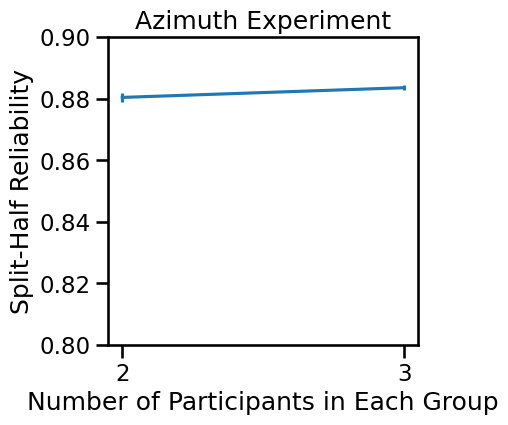

In [25]:
from tqdm.auto import tqdm
import scipy.stats as stats


# n
## Azim only experiment:
azim_data =  grouped_part_results[grouped_part_results.distractor_elev_delta == 0].copy()
azim_data = azim_data[(azim_data.n_distractors == 2)]
azim_data = azim_data[azim_data.participant != 'participant_001']
azim_data = azim_data[azim_data.snr <= 0]

n_parts = azim_data.participant.nunique()
unique_participants = azim_data.participant.unique()

max_split_size = n_parts // 2
print(max_split_size)

split_half_reliabilities = []
n_boots = 10000

for k in tqdm(range(2, max_split_size+1)):
    # for cond in tqdm(conds, leave=False):
    split_corrs = np.zeros(n_boots)
    for i in range(n_boots):
        # get group 1
        group_1_names = np.random.choice(unique_participants, k, replace=False)
        group_1 = azim_data[azim_data.participant.isin(group_1_names)].correct_mean.values
        # get group 2
        group_2_names = np.random.choice(unique_participants[~np.isin(unique_participants, group_1_names)], k, replace=False)
        group_2 = azim_data[azim_data.participant.isin(group_2_names)].correct_mean.values
        # get r
        r = stats.pearsonr(group_1, group_2)[0] 
        split_corrs[i] = r  
    # get condition mean and std
    mean_r = np.nanmean(split_corrs)
    std_err =  np.nanstd(split_corrs) / np.sqrt(n_boots) 
    corrected_mean = (2 * mean_r) / ( 1 + mean_r)
    corrected_error = (2 * std_err) / ( 1 + std_err)

    split_half_reliabilities.append({"k":k, "mean_cor":corrected_mean, "sem": corrected_error})


plt.figure(figsize=(4,4))        
plt.errorbar([x['k'] for x in split_half_reliabilities], [x['mean_cor'] for x in split_half_reliabilities], yerr=[x['sem'] for x in split_half_reliabilities])
plt.xlabel("Number of Participants in Each Group")
plt.ylabel("Split-Half Reliability")
plt.title("Azimuth Experiment")
plt.xticks([x['k'] for x in split_half_reliabilities])
plt.ylim(0.8,0.9)

3


  0%|          | 0/2 [00:00<?, ?it/s]

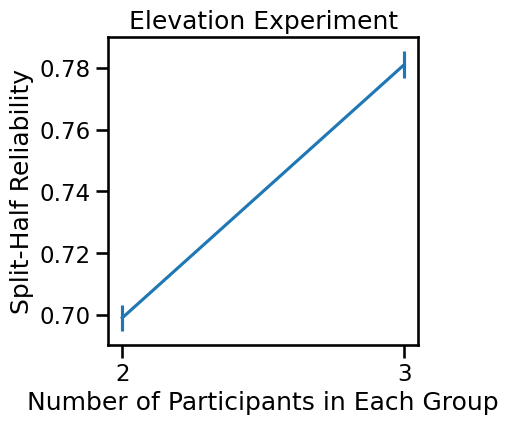

In [20]:



## Elev only experiment:
elev_data = grouped_part_results[grouped_part_results.distractor_azim == 0].copy()
# elev_data = elev_data[(elev_data.n_distractors == 2)]
elev_data = elev_data[elev_data.participant != 'participant_001']

elev_data.drop(elev_data[(elev_data['participant'].str.contains('pilot')) & (elev_data.n_distractors == 2)].index, inplace=True)


# elev_data = elev_data[~elev_data.participant.str.contains('pilot')]
elev_data = elev_data[elev_data.snr <= 0]

n_parts = elev_data.participant.nunique()
unique_participants = elev_data.participant.unique()

max_split_size = n_parts // 2
print(max_split_size)

split_half_reliabilities = []
n_boots = 10000

for k in tqdm(range(2, max_split_size+1)):
    # for cond in tqdm(conds, leave=False):
    split_corrs = np.zeros(n_boots)
    for i in range(n_boots):
        # get group 1
        group_1_names = np.random.choice(unique_participants, k, replace=False)
        group_1 = elev_data[elev_data.participant.isin(group_1_names)].correct_mean.values
        # get group 2
        group_2_names = np.random.choice(unique_participants[~np.isin(unique_participants, group_1_names)], k, replace=False)
        group_2 = elev_data[elev_data.participant.isin(group_2_names)].correct_mean.values
        # get r
        r = stats.pearsonr(group_1, group_2)[0] 
        split_corrs[i] = r  
    # get condition mean and std
    mean_r = np.nanmean(split_corrs)
    std_err =  np.nanstd(split_corrs) / np.sqrt(n_boots) 
    corrected_mean = (2 * mean_r) / ( 1 + mean_r)
    corrected_error = (2 * std_err) / ( 1 + std_err)

    split_half_reliabilities.append({"k":k, "mean_cor":corrected_mean, "sem": corrected_error})

plt.figure(figsize=(4,4))        
plt.errorbar([x['k'] for x in split_half_reliabilities], [x['mean_cor'] for x in split_half_reliabilities], yerr=[x['sem'] for x in split_half_reliabilities])
plt.xlabel("Number of Participants in Each Group")
plt.ylabel("Split-Half Reliability")
plt.title("Elevation Experiment")
plt.xticks([x['k'] for x in split_half_reliabilities]);

## Run bootstrap using threshold estimates 

In [18]:
from tqdm.auto import tqdm
import scipy.stats as stats


# n
## Azim only experiment:
azim_data =  grouped_part_results[grouped_part_results.distractor_elev_delta == 0].copy()
azim_data = azim_data[(azim_data.n_distractors == 2)]
# azim_data = azim_data[azim_data.participant != 'participant_001']
azim_data = azim_data[azim_data.snr.isin(np.arange(-9, 7))]

n_parts = azim_data.participant.nunique()
unique_participants = azim_data.participant.unique()

max_split_size = n_parts // 2
print(max_split_size)

split_half_reliabilities = []
n_boots = 1000

for k in tqdm(range(2, max_split_size+1)):
    # for cond in tqdm(conds, leave=False):
    split_corrs = np.zeros(n_boots)
    for i in tqdm(range(n_boots), leave=False):
        # get group 1
        group_1_names = np.random.choice(unique_participants, k, replace=False)
        # get group 1 thresholds 
        group_1 = azim_data[azim_data.participant.isin(group_1_names)]
        azim_thresholds = []
        # p0 = [0.0, -4, 4]
        for azim, group in group_1.groupby(['distractor_azim']): #, 'gender_cond']):
            thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values)#, p0=p0)
            if np.isnan(thresh):
                print(f"Threshold is nan for azim {azim}")
            azim_thresholds.append({'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
        group_1_thresholds = pd.DataFrame(azim_thresholds).threshold
        # get group 2
        group_2_names = np.random.choice(unique_participants[~np.isin(unique_participants, group_1_names)], k, replace=False)
        group_2 = azim_data[azim_data.participant.isin(group_2_names)]
        azim_thresholds = []
        # p0 = [0.0, -4, 4]
        for azim, group in group_2.groupby(['distractor_azim']): #, 'gender_cond']):
            thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values)#, p0=p0)
            if np.isnan(thresh):
                print(f"Threshold is nan for azim {azim}")
            azim_thresholds.append({'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
        group_2_thresholds = pd.DataFrame(azim_thresholds).threshold
        
        # get r
        try:
            r = stats.pearsonr(group_1_thresholds, group_2_thresholds)[0] 
        except:
            r = np.nan
        split_corrs[i] = r  
    # get condition mean and std
    mean_r = np.nanmean(split_corrs)
    std_err =  np.nanstd(split_corrs) / np.sqrt(n_boots) 
    corrected_mean = (2 * mean_r) / ( 1 + mean_r)
    corrected_error = (2 * std_err) / ( 1 + std_err)

    split_half_reliabilities.append({"k":k, "mean_cor":corrected_mean, "sem": corrected_error})


plt.figure(figsize=(4,4))        
plt.errorbar([x['k'] for x in split_half_reliabilities], [x['mean_cor'] for x in split_half_reliabilities], yerr=[x['sem'] for x in split_half_reliabilities])
plt.xlabel("Number of Participants in Each Group")
plt.ylabel("Split-Half Reliability")
plt.title("Azimuth thresholds")
plt.xticks([x['k'] for x in split_half_reliabilities])
plt.ylim(0.8,0.9)

3


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for azim 0
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for azim 10
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for azim 10
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for azim 0
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for azim 0
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for azim 10
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for azim 10
Optimal parameters not found: The maximum number of function evaluations is exceeded.
Threshold is nan for azim 0
Optimal parameters not found: The maximum number of function evaluations is exceeded

KeyboardInterrupt: 

In [37]:
# ### Drop part with missing data
# grouped_part_results = grouped_part_results[grouped_part_results.participant != 'participant_001']
# grouped_part_results = grouped_part_results[grouped_part_results.participant != 'participant_002']

In [38]:
from tqdm.auto import tqdm
import scipy.stats as stats


# n
grouped_part_results = grouped_part_results[~(grouped_part_results.participant.str.contains('pilot')) & (grouped_part_results.n_distractors == 2)]

n_parts = grouped_part_results.participant.nunique()
unique_participants = grouped_part_results.participant.unique()

max_split_size = n_parts // 2


split_half_reliabilities = []
n_boots = 10000

for k in tqdm(range(1, max_split_size+1)):
    # for cond in tqdm(conds, leave=False):
    split_corrs = np.zeros(n_boots)
    for i in range(n_boots):
        # get group 1
        group_1_names = np.random.choice(unique_participants, k, replace=False)
        group_1 = grouped_part_results[grouped_part_results.participant.isin(group_1_names)].correct_mean.values
        # get group 2
        group_2_names = np.random.choice(unique_participants[~np.isin(unique_participants, group_1_names)], k, replace=False)
        group_2 = grouped_part_results[grouped_part_results.participant.isin(group_2_names)].correct_mean.values
        # get r
        r = stats.pearsonr(group_1, group_2)[0] 
        split_corrs[i] = r  
    # get condition mean and std
    mean_r = np.nanmean(split_corrs)
    std_err =  np.nanstd(split_corrs) / np.sqrt(n_boots) 
    corrected_mean = (2 * mean_r) / ( 1 + mean_r)
    corrected_error = (2 * std_err) / ( 1 + std_err)

    split_half_reliabilities.append({"k":k, "mean_cor":corrected_mean, "sem": corrected_error})

        


  0%|          | 0/2 [00:00<?, ?it/s]

ValueError: x and y must have the same length.

In [ ]:
split_half_reliabilities

[{'k': 1, 'mean_cor': 0.9121146064329383, 'sem': 0.00040968764286219896}]